In [1]:
# script to plot PRCs and oddsRs for ClinVar non-coding variants
# getting publication ready

In [2]:
# import packages
import pandas as pd
import pybedtools
import os
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as mpl
from scipy import stats
import numpy as np
import math
from pywaffle import Waffle
from collections import Counter
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn import metrics
from tqdm import tqdm
from collections import Counter
import itertools
import matplotlib.patches as mpatches

In [3]:
# define function to return emVar status
def add_emvar (pred_df,
               cell_type,
               skew_cutoff):
    # make a list for emvar status
    emvar_list = []
    for skew in pred_df[f'{cell_type}_skew_pred']:
        if abs(skew) >= skew_cutoff:
            emvar_list.append(1)
        else:
            emvar_list.append(0)
    # add column to DF
    pred_df[f'{cell_type}_emvar'] = emvar_list
    return pred_df

In [4]:
# annotate emVars in predictions
def annotate_preds (df,
                    skew_thresh):
    # add max activity
    df = add_max_act(df)
    # add k562 emVar status
    df = add_emvar(df,
                   'k562',
                   skew_thresh)
    # add hepg2 emVar status
    df = add_emvar(df,
                   'hepg2',
                   skew_thresh)
    # add sknsh emVar status
    df = add_emvar(df,
                   'sknsh',
                   skew_thresh)
    # add emVar any column
    df['emvar_any'] = [1 if [i,j,k].count(1) > 0 else 0 for i,j,k in zip(df['k562_emvar'],
                                                                         df['hepg2_emvar'],
                                                                         df['sknsh_emvar'])]
    return df

In [5]:
# define function to return DF of Precision and Recall of Experimental for CRE, emVar, and emVar + CRE
def empirical_precision_recall_cCREs (df):
    # split df into pathogenic and take a matched sample
    pos_df = df[df['clinsig'].isin(['Pathogenic',
                                    'Likely_pathogenic'])]
    # get random negative sample
    neg_sample = df[~df['clinsig'].isin(['Pathogenic',
                                         'Likely_pathogenic'])].sample(len(pos_df))
    # recombine df
    df = pd.concat([pos_df,
                    neg_sample])
    # make binary list of true positives
    causal_true_false = [1 if i == 1 else 0 for i in df['pathogenic']]
    ### PLS ###
    # make list of hits/misses
    pls_hit_miss = [1 if i == 1 else 0 for i in df['250bp_promoter']]
    # calculate precision
    pls_precision = precision_score(causal_true_false,
                                    pls_hit_miss)
    # calculate recall
    pls_recall = recall_score(causal_true_false,
                              pls_hit_miss)
    # add df of precision/recall to dict
    PLS_prc = pd.DataFrame({'feature' : ['250bp Promoter'],
                            'precision' : [pls_precision],
                            'recall' : [pls_recall]})
    ### pELS ###
    # make list of hits/misses
    #pELS_hit_miss = [1 if i == 1 else 0 for i in df['pELS']]
    # calculate precision
    #pELS_precision = precision_score(causal_true_false,
    #                                 pELS_hit_miss)
    # calculate recall
    #pELS_recall = recall_score(causal_true_false,
    #                           pELS_hit_miss)
    # add df of precision/recall to dict
    #pELS_prc = pd.DataFrame({'feature' : ['pELS'],
    #                         'precision' : [pELS_precision],
    #                         'recall' : [pELS_recall]})
    ### dELS ###
    #dELS_hit_miss = [1 if i == 1 else 0 for i in df['dELS']]
    # calculate precision
    #dELS_precision = precision_score(causal_true_false,
    #                                 dELS_hit_miss)
    # calculate recall
    #dELS_recall = recall_score(causal_true_false,
    #                           dELS_hit_miss)
    # add df of precision/recall to dict
    #dELS_prc = pd.DataFrame({'feature' : ['dELS'],
    #                         'precision' : [dELS_precision],
    #                         'recall' : [dELS_recall]})
    ### DHS ###
    dhs_hit_miss = [1 if i == 1 else 0 for i in df['DHS']]
    # calculate precision
    dhs_precision = precision_score(causal_true_false,
                                    dhs_hit_miss)
    # calculate recall
    dhs_recall = recall_score(causal_true_false,
                              dhs_hit_miss)
    # add df of precision/recall to dict
    dhs_prc = pd.DataFrame({'feature' : ['DHS'],
                            'precision' : [dhs_precision],
                            'recall' : [dhs_recall]})
    ### CRE ###
    cre_hit_miss = [1 if i == 1 else 0 for i in df['CRE']]
    # calculate precision
    cre_precision = precision_score(causal_true_false,
                                    cre_hit_miss)
    # calculate recall
    cre_recall = recall_score(causal_true_false,
                              cre_hit_miss)
    # add df of precision/recall to dict
    cre_prc = pd.DataFrame({'feature' : ['CRE'],
                            'precision' : [cre_precision],
                            'recall' : [cre_recall]})
    # combine all DFs
    all_prc = pd.concat([PLS_prc,
                         #pELS_prc,
                         #dELS_prc,
                         dhs_prc,
                         cre_prc])#,
                         #emvar_prc,
                         #cre_emvar_prc])
    print(all_prc)
    return df, all_prc;

In [6]:
### Define function to generate PRCs for Malinois Predictions ###
def precision_recall_clinvar (df, list_of_thresholds, n_tests, feature):
    # make a dictionary for storing dfs
    prc_dfs = {}
    prc_preds = {}
    ids = []
    # iterate through list of thresholds
    for test in tqdm(range(0, n_tests)):
        # make a list
        #dfs2concat = []
        # get pathogenic variants
        pos_df = df[df['clinsig'].isin(['Pathogenic',
                                        'Likely_pathogenic'])]
        # get random negative sample
        neg_sample = df[~df['clinsig'].isin(['Pathogenic',
                                             'Likely_pathogenic'])].sample(len(pos_df))
        samp_df = pd.concat([pos_df,
                             neg_sample])
        # add tested preds to dictionary
        prc_preds.update({f'{test}_preds' : samp_df})
        ids.append(df['id'].tolist())
        # make lists for holding precisions
        emvar_precisions = []
        # make lists for holding recalls=
        emvar_recalls = []
        # test_num
        test_name = []
        for skew in list_of_thresholds:
            # annotate preds
            ann_df = annotate_preds(samp_df, skew)
            # make binary list of true positives
            causal_true_false = [1 if i == 1 else 0 for i in ann_df['pathogenic']]
            ### emvar ###
            # make list of hits/misses
            emvar_hit_miss = [1 if i == 1 else 0 for i in ann_df['emvar_any']]
            # calculate precision
            emvar_precision = precision_score(causal_true_false,
                                              emvar_hit_miss)
            # calculate recall
            emvar_recall = recall_score(causal_true_false,
                                        emvar_hit_miss)
            emvar_precisions.append(emvar_precision)
            emvar_recalls.append(emvar_recall)
            test_name.append(f'test_{test}_{skew}')
        # update dictionary
        prc_dfs.update({f'{skew}_{test}' : pd.DataFrame({'skew_threshold' : test_name,
                                                         'precision' : emvar_precisions,
                                                         'recall' : emvar_recalls,
                                                         'feature' : [feature for i in range(len(emvar_recalls))]})})
    oddsR_clinvar = pd.concat(prc_dfs.values()).sort_values(by='skew_threshold')
    return oddsR_clinvar, prc_preds;

In [7]:
# define function to add 95% confidence interval to oddsR DFs, return DF of oddsR emVar, pval test, confidence interval, bin
def add_confidence (two_by_table,
                    df2pass,
                    feature):
    try:
        # break out 2 x 2 table into a,b,c,d
        a = two_by_table['Pathogenic'].tolist()[0]
        b = two_by_table['Benign'].tolist()[0]
        c = two_by_table['Pathogenic'].tolist()[1]
        d = two_by_table['Benign'].tolist()[1]
        # get oddsR from bar df
        oddsR = df2pass['oddsR'].tolist()[0]
        # get p_val from bar df
        p_val = df2pass['p_val'].tolist()[0]
        # calculate upper/lower 95% confidence intervals
        upper_95 = math.e**(np.log(oddsR) + 1.96 * np.sqrt(1/a + 1/b + 1/c + 1/d))
        lower_95 = math.e**(np.log(oddsR) - 1.96 * np.sqrt(1/a + 1/b + 1/c + 1/d))
        # make a df with oddsR, p value, and confidence interval
        out_df = pd.DataFrame({'OddsR' : [oddsR],
                               'p_val' : [p_val],
                               'upperCI' : [upper_95],
                               'lowerCI' : [lower_95]}, index=[feature])
    except ZeroDivisionError:
        out_df = pd.DataFrame({'OddsR' : [oddsR],
                               'p_val' : [p_val],
                               'upperCI' : [np.NaN],
                               'lowerCI' : [np.NaN]}, index=[feature])
        
    return out_df

In [8]:
### Define function to calcualte Odds Ratios - DF should be filtered for feature of choice ###
def calc_oddsR (df,
               feature):
    # split exon_filtered preds into path and benign
    path_preds = df[df['clinsig'].isin(['Pathogenic',
                                        'Likely_pathogenic'])]
    benign_preds = df[df['clinsig'].isin(['Benign',
                                          'Likely_benign'])]
    # make a 2x2 table for calculating oddsR
    twoBytwo =  pd.DataFrame({'Pathogenic' : [path_preds['emvar_any'].tolist().count(1),
                                              path_preds['emvar_any'].tolist().count(0)],
                              'Benign' : [benign_preds['emvar_any'].tolist().count(1),
                                          benign_preds['emvar_any'].tolist().count(0)]})
    # calculate odds ratio
    oddsr_path_emvar, pval_path_emvar = stats.fisher_exact(twoBytwo)
    # make a DF
    df2pass = pd.DataFrame({'feature' : [feature],
                              'oddsR' : [oddsr_path_emvar],
                              'p_val' : [pval_path_emvar]})
    # calculate confidence intervals
    with_confidence = add_confidence(twoBytwo,
                                     df2pass,
                                     feature)
    return with_confidence, twoBytwo;

In [9]:
### Define function to calcualte Odds Ratios - DF should be filtered for feature of choice ###
def calc_oddsR_dhs (df,
               feature):
    # split exon_filtered preds into path and benign
    path_preds = df[df['clinsig'].isin(['Pathogenic',
                                        'Likely_pathogenic'])]
    benign_preds = df[df['clinsig'].isin(['Benign',
                                          'Likely_benign'])]
    # make a 2x2 table for calculating oddsR
    twoBytwo =  pd.DataFrame({'Pathogenic' : [path_preds['DHS'].tolist().count(1),
                                              path_preds['DHS'].tolist().count(0)],
                              'Benign' : [benign_preds['DHS'].tolist().count(1),
                                          benign_preds['DHS'].tolist().count(0)]})
    # calculate odds ratio
    oddsr_path_dhs, pval_path_dhs = stats.fisher_exact(twoBytwo)
    # make a DF
    df2pass = pd.DataFrame({'feature' : [feature],
                              'oddsR' : [oddsr_path_dhs],
                              'p_val' : [pval_path_dhs]})
    # calculate confidence intervals
    with_confidence = add_confidence(twoBytwo,
                                     df2pass,
                                     feature)
    return with_confidence, twoBytwo;

In [10]:
def vcf2df (file):
    pred_df = pd.read_csv(file, sep = '\t')
    # make lists of preds for new column
    # k562
    k_ref = []
    k_alt = []
    k_skew = []
    # hepg2
    h_ref = []
    h_alt = []
    h_skew = []
    # sknsh
    s_ref = []
    s_alt = []
    s_skew = []
    # parse predictions in 'INFO' column
    for i in tqdm(pred_df['INFO']):
        all_preds = i.split(';')
        # k562
        k_ref.append(float(all_preds[0].split('=')[-1]))
        k_alt.append(float(all_preds[3].split('=')[-1]))
        k_skew.append(float(all_preds[6].split('=')[-1]))
        # hepg2
        h_ref.append(float(all_preds[1].split('=')[-1]))
        h_alt.append(float(all_preds[4].split('=')[-1]))
        h_skew.append(float(all_preds[7].split('=')[-1]))
        # sknsh
        s_ref.append(float(all_preds[2].split('=')[-1]))
        s_alt.append(float(all_preds[5].split('=')[-1]))
        s_skew.append(float(all_preds[8].split('=')[-1]))
    
    df = pd.DataFrame({'chrom' : pred_df['chrom'],
                       'pos' : pred_df['pos'],
                       'id' : pred_df['id'],
                       'ref' : pred_df['ref'],
                       'alt' : pred_df['alt'],
                       'k562_ref_pred' : k_ref,
                       'k562_alt_pred' : k_alt,
                       'k562_skew_pred' : k_skew,
                       'hepg2_ref_pred' : h_ref,
                       'hepg2_alt_pred' : h_alt,
                       'hepg2_skew_pred' : h_skew,
                       'sknsh_ref_pred' : s_ref,
                       'sknsh_alt_pred' : s_alt,
                       'sknsh_skew_pred' : s_skew})
    return df

In [11]:
#### Filtering of coding sequence variants ####
#### DF has been saved so we can skip this ####
### Open ClinVar and Exon BED Files ###
# open clinvar BED file
#clinvar_bed = pybedtools.BedTool('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ClinVar/bed_files/clinvar_093023.bed')
# open protein coding exon file
#gencode_exon_bed = pybedtools.BedTool('/Users/buttsj/Downloads/gencode.v44.basic.annotation.exons.splice.autosomes.v2.bed')
# subtract clinvar variants from exon annotations
#non_exon_clinvar = clinvar_bed.subtract(gencode_exon_bed)
### Open predictions, annotate emvars, and filter exonic variants ###
# open all Clinvar Preds
#all_clinvar_preds = pd.read_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ClinVar/predictions/all.clinvar.preds.annotated.017.vcf',
#                                        sep = '\t')
# add emvar annotations
#all_clinvar_preds = annotate_preds(all_clinvar_preds, 
#                                   .5)
# filter preds for exon filter clinvar
#exon_filtered_preds = all_clinvar_preds[all_clinvar_preds['id'].isin(non_exon_clinvar.to_dataframe()['name'])]

In [12]:
#### Commands intersect ENCODE cCRE BED Files with exon filtered predictions for adding annotations ####
#### DF has been saved to disk so we can skip this, re-run if we wish to verify ####

### Open BED files for promoters (250bp, ours) and ENCODE PLS, pELS, and dELS ###
# open updated promtoer bed file for annotating preds
#twoFifty_pros = pybedtools.BedTool('/Users/buttsj/Dropbox (JAX)/Variant_Effects/cosmic/final_bed_files/gencode.v44.protein.coding.canonical.autosomes.0.based.250bp.bed')
# convert filtered preds to BED format
#exon_filtered_pred_bed = pybedtools.BedTool.from_dataframe(pd.DataFrame({'chrom' : exon_filtered_preds['chrom'],
#                                                                         'start' : [i-1 for i in exon_filtered_preds['pos']],
#                                                                         'end' : exon_filtered_preds['pos'],
#                                                                         'name' : exon_filtered_preds['id']}))
# open ENCODE PLS bed
#PLS_bed = pybedtools.BedTool('/Users/buttsj/Dropbox (JAX)/Variant_Effects/encode_ccre_beds/GRCh38-PLS.V4.bed.gz')

# open ENCODE pELS bed
#pELS_bed = pybedtools.BedTool('/Users/buttsj/Dropbox (JAX)/Variant_Effects/encode_ccre_beds/GRCh38-pELS.V4.bed.gz')

# open ENCODE dELS bed
#dELS_bed = pybedtools.BedTool('/Users/buttsj/Dropbox (JAX)/Variant_Effects/encode_ccre_beds/GRCh38-dELS.V4.bed.gz')

### Intersect exon filtered ClinVar Predictions with Annotation BEDs ###
# intersect filtered clinvar preds with promoters
#clinvar_promoter_vars = exon_filtered_pred_bed.intersect(twoFifty_pros, wa=True).to_dataframe()
# intersect filtered clinvar preds with PLS
#clinvar_pls_vars = exon_filtered_pred_bed.intersect(PLS_bed, wa=True).to_dataframe()
# intersect filtered clinvar preds with pELS
#clinvar_pELS_vars = exon_filtered_pred_bed.intersect(pELS_bed, wa=True).to_dataframe()
# intersect clinvar_preds with dELS
#clinvar_dELS_vars = exon_filtered_pred_bed.intersect(dELS_bed, wa=True).to_dataframe()
# make dictionaries for more quickly pulling IDs
# 250bp pro
#clin_pro_dict = dict(zip(clinvar_promoter_vars['name'],
#                         [1 for i in range(len(clinvar_promoter_vars))]))
# PLS
#clin_pls_dict = dict(zip(clinvar_pls_vars['name'],
#                         [1 for i in range(len(clinvar_pls_vars))]))
# pELS
#clin_pELS_dict = dict(zip(clinvar_pELS_vars['name'],
#                          [1 for i in range(len(clinvar_pELS_vars))]))
# dELS
#clin_dELS_dict = dict(zip(clinvar_dELS_vars['name'],
#                          [1 for i in range(len(clinvar_dELS_vars))]))

### Add Columns with binary annotations for promoters, etc. to predictions DF ###
# promoter
#exon_filtered_preds['250bp_promoter'] = [clin_pro_dict.get(i) if i in clin_pro_dict.keys() else 0 for i in tqdm(exon_filtered_preds['id'])]
# PLS
#exon_filtered_preds['PLS'] = [clin_pls_dict.get(i) if i in clin_pls_dict.keys() else 0 for i in tqdm(exon_filtered_preds['id'])]
# pELS
#exon_filtered_preds['pELS'] = [clin_pELS_dict.get(i) if i in clin_pELS_dict.keys() else 0 for i in tqdm(exon_filtered_preds['id'])]
# dELS
#exon_filtered_preds['dELS'] = [clin_dELS_dict.get(i) if i in clin_dELS_dict.keys() else 0 for i in tqdm(exon_filtered_preds['id'])]
### Open Mueleman DHS data, convert to BED file, and add to predictions ###
# open DHS
#mueleman_dhs = pd.read_csv('/Users/buttsj/Downloads/ENCFF503GCK.tsv',
#                           sep = '\t',
#                           low_memory=False)
# fiilter muelman dhs and convert to BED file
#mueleman_bed = pybedtools.BedTool.from_dataframe(mueleman_dhs.filter(['seqname',
#                                                                      'start',
#                                                                      'end',
#                                                                      'mean_signal']))
# intersect DHS and clinvar variants
#clinvar_dhs_vars = exon_filtered_pred_bed.intersect(mueleman_bed, wa=True).to_dataframe()
# makae dict
#clin_dhs_dict = dict(zip(clinvar_dhs_vars['name'],
#                         [1 for i in range(len(clinvar_dhs_vars))]))
# add dhs annotation to preds
#exon_filtered_preds['DHS'] = [clin_dhs_dict.get(i) if i in clin_dhs_dict.keys() else 0 for i in tqdm(exon_filtered_preds['id'])]

### combine all CRE related features into one category and add to predictions DF ###
# combine all variants overlapping CRE features into master 'CRE' list
#all_feature_vars = pd.concat([clinvar_pls_vars,
#                              clinvar_pELS_vars,
#                              clinvar_dELS_vars,
#                              clinvar_dhs_vars]).drop_duplicates()['name'].tolist()
# make a dictionary
#all_feature_dict = dict(zip(all_feature_vars,
#                            [1 for i in range(len(all_feature_vars))]))
# add CRE annotation to preds
#exon_filtered_preds['CRE'] = [all_feature_dict.get(i) if i in all_feature_dict.keys() else 0 for i in tqdm(exon_filtered_preds['id'])]

In [20]:
# open exon/splice site filtered predictions, see above comments #
exon_filtered_preds = pd.read_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/Kipoi_Comparisons/clinvar/exon_splice_filtered_annotated_clinvar_preds_017.txt',
                                  sep = '\t')

In [26]:
# combine Benign/Likely_benign into 'Benign' and Pathogenic/Likely_pathogenic into 'Pathogenic'
benign_preds = exon_filtered_preds[exon_filtered_preds['clinsig'].isin(['Benign',
                                                                        'Likely_benign'])]
path_preds = exon_filtered_preds[exon_filtered_preds['clinsig'].isin(['Pathogenic',
                                                                      'Likely_pathogenic'])]
# get proportion of non-dhs Benign variants
prop_non_dhs_benign = len(benign_preds[(benign_preds['DHS'] == 0) &
                                       (benign_preds['emvar_any'] == 1)]) / len(benign_preds[(benign_preds['DHS'] == 0)])
# get numbers for populating 2x2 table
n_non_dhs_benign = len(benign_preds[(benign_preds['DHS'] == 0)])
n_non_dhs_benign_emvars = len(benign_preds[(benign_preds['DHS'] == 0) &
                                           (benign_preds['emvar_any'] == 1)])
# get proportion of non-dhs Pathogenic variants
prop_non_dhs_path = len(path_preds[(path_preds['DHS'] == 0) &
                                   (path_preds['emvar_any'] == 1)]) / len(path_preds[(path_preds['DHS'] == 0)])
# get numbers for populating 2x2 table
n_non_dhs_path = len(path_preds[(path_preds['DHS'] == 0)])
n_non_dhs_path_emvars = len(path_preds[(path_preds['DHS'] == 0) &
                                       (path_preds['emvar_any'] == 1)])

In [22]:
# get proportion of benign emvars in dhs
prop_dhs_benign = len(benign_preds[(benign_preds['DHS'] == 1) &
                                          (benign_preds['emvar_any'] == 1)]) / len(benign_preds[(benign_preds['DHS'] == 1)])
# get proportion of pathogenic emvars in dhs
prop_dhs_path = len(path_preds[(path_preds['DHS'] == 1) &
                                 (path_preds['emvar_any'] == 1)]) / len(path_preds[(path_preds['DHS'] == 1)])
# get numbers for populating 2x2 table
n_dhs_benign = len(benign_preds[(benign_preds['DHS'] == 1)])
n_dhs_benign_emvar = len(benign_preds[(benign_preds['DHS'] == 1) &
                                      (benign_preds['emvar_any'] == 1)])
# get numbers for populating 2x2 table
n_dhs_path = len(path_preds[path_preds['DHS'] == 1])
n_dhs_path_emvars = len(path_preds[(path_preds['DHS'] == 1) &
                                   (path_preds['emvar_any'] == 1)])

In [23]:
# get proportion of benign emvars in promoters
prop_pro_benign = len(benign_preds[(benign_preds['250bp_promoter'] == 1) &
                                   (benign_preds['emvar_any'] == 1)]) / len(benign_preds[benign_preds['250bp_promoter'] == 1])

# get numbers for populating 2x2 table
n_pro_benign_emvars = len(benign_preds[(benign_preds['250bp_promoter'] == 1) &
                                       (benign_preds['emvar_any'] == 1)])
n_pro_benign = len(benign_preds[benign_preds['250bp_promoter'] == 1])
# get proportion of pathogenic emvars in promoters
prop_pro_path = len(path_preds[(path_preds['250bp_promoter'] == 1) &
                               (path_preds['emvar_any'] == 1)]) / len(path_preds[path_preds['250bp_promoter'] == 1])
# get numbers for populating 2x2 table
n_pro_path_emvars = len(path_preds[(path_preds['250bp_promoter'] == 1) &
                                   (path_preds['emvar_any'] == 1)])
n_pro_path = len(path_preds[path_preds['250bp_promoter'] == 1])                   

In [35]:
# make a df for making a bar plot
# benign
benign2bar = pd.DataFrame({'Feature' : ['Non-DHS', 'DHS', '250bp Promoter'],
                          'Proportion' : [prop_non_dhs_benign, prop_dhs_benign, prop_pro_benign]})
# add benign label for making stacked bar plot
benign2bar['pathogenicity'] = ['Benign' for i in range(len(benign2bar))]
# pathogenic
path2bar = pd.DataFrame({'Feature' : ['Non-DHS', 'DHS', '250bp Promoter'],
                         'Proportion' : [prop_non_dhs_path, prop_dhs_path, prop_pro_path]})
# add pathogenic label for making stacked bar plot
path2bar['pathogenicity'] = ['Pathogenic' for i in range(len(path2bar))]
# combine pathogenic and benign for plotting
cat2plot_emvar_prop = pd.concat([benign2bar,
                                 path2bar])

In [36]:
cat2plot_emvar_prop

,Feature,Proportion,pathogenicity
0,Non-DHS,0.013986,Benign
1,DHS,0.039097,Benign
2,250bp Promoter,0.068770,Benign
0,Non-DHS,0.028986,Pathogenic
1,DHS,0.144737,Pathogenic
2,250bp Promoter,0.471698,Pathogenic


In [37]:
# make a 2x2 table for each set for doing chi-square test
# non-dhs
non_dhs_2x2 = pd.DataFrame({'Pathogenic' : [n_non_dhs_path_emvars, n_non_dhs_path],
                            'Benign' : [n_non_dhs_benign_emvars, n_non_dhs_benign]})
# promoter
pro_2x2 = pd.DataFrame({'Pathogenic' : [n_pro_path_emvars, n_pro_path],
                               'Benign' : [n_pro_benign_emvars, n_pro_benign]})
# dhs all
dhs_all_2x2 = pd.DataFrame({'Pathogenic' : [n_dhs_path_emvars, n_dhs_path],
                               'Benign' : [n_dhs_benign_emvar, n_dhs_benign]})

In [30]:
def perform_chi_square_test(data, col1, col2):
    # Creating a contingency table
    contingency_table = data
    print(contingency_table)
    # Performing the Chi-Square Test
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

    # Interpreting the result
    significant = p < 0.05  # 5% significance level
    return chi2, p, significant

In [38]:
# get chi square for each subset
# non-dhs
perform_chi_square_test(non_dhs_2x2, 'Pathogenic', 'Benign')

   Pathogenic  Benign
0          10    1472
1         345  105245


(4.355488208070411, 0.03688988425862125, True)

In [39]:
# dhs
perform_chi_square_test(dhs_all_2x2, 'Pathogenic', 'Benign')

   Pathogenic  Benign
0          33    2228
1         228   56987


(53.64304316768516, 2.404335703407497e-13, True)

In [40]:
# promoters
perform_chi_square_test(pro_2x2, 'Pathogenic', 'Benign')

   Pathogenic  Benign
0          25     170
1          53    2472


(70.90527453544462, 3.747946102722254e-17, True)

<Figure size 1800x1200 with 0 Axes>

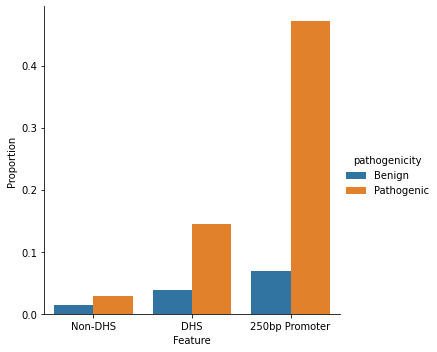

In [43]:
# plot in square grid
mpl.figure(dpi=300)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
# make plot
sns.catplot(data=cat2plot_emvar_prop,
            x='Feature',
            y='Proportion',
            hue='pathogenicity',
            kind='bar')
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/pathogenic_and_benign_emvar_stacked_bar_v2.pdf')

In [44]:
### AVERAGE ###
# calculate enrichment of emVars in pathogenic vs benign variants
# All ClinVar
all_clinvar2plot, all_clinvar_2x2 = calc_oddsR(exon_filtered_preds,
                                               'All ClinVar')
# dELS
dels_clinvar2plot, dels_clinvar_2x2 = calc_oddsR(exon_filtered_preds[exon_filtered_preds['dELS'] == 1],
                                                 'dELS')
# pELS
pels_clinvar2plot, pels_clinvar_2x2 = calc_oddsR(exon_filtered_preds[exon_filtered_preds['pELS'] == 1],
                                                 'pELS')
# PLS
pls_clinvar2plot, pls_clinvar_2x2 = calc_oddsR(exon_filtered_preds[exon_filtered_preds['PLS'] == 1],
                                               'PLS')
# 250bp Promoter
twoFifty_clinvar2plot, twoFifty_clinvar_2x2 = calc_oddsR(exon_filtered_preds[exon_filtered_preds['250bp_promoter'] == 1],
                                                         '250bp Promoter')
# DHS
DHS_clinvar2plot, DHS_clinvar_2x2 = calc_oddsR(exon_filtered_preds[(exon_filtered_preds['DHS'] == 1) &
                                                                   (exon_filtered_preds['250bp_promoter'] == 0)],
                                                               'DHS')
# CRE
cre_clinvar2plot, cre_clinvar_2x2 = calc_oddsR(exon_filtered_preds[exon_filtered_preds['CRE'] == 1],
                                               'CRE')
# concatenate all together
cat_odds_or = pd.concat([all_clinvar2plot,
                         twoFifty_clinvar2plot,
                         DHS_clinvar2plot])
# add a column to concatenated df with label for y axis on plot below
cat_odds_or['plot_labs'] = ['All ClinVar',
                            '250bp Promoter',
                            'DHS']
# define a color palette for recurrence, etc.
pastel_pal = sns.color_palette('Dark2')

feature_palette = {'All ClinVar' : '#1b9e77',
                   'dELS' : '#d95f02',
                   'pELS' : '#7570b3',
                   'PLS' : '#a6761d',
                   '250bp Promoter' : '#e7298a',
                   'DHS' : '#66a61e',
                   'cCRE' : '#e6ab02'}

In [45]:
# calculate oddsR a variant is pathogenic based on residing in a CRE #
calc_oddsR_dhs(exon_filtered_preds, 'DHS_Empirical')

(                 OddsR     p_val   upperCI   lowerCI
 DHS_Empirical  1.22051  0.020205  1.443202  1.032181,
    Pathogenic  Benign
 0         228   56987
 1         345  105245)

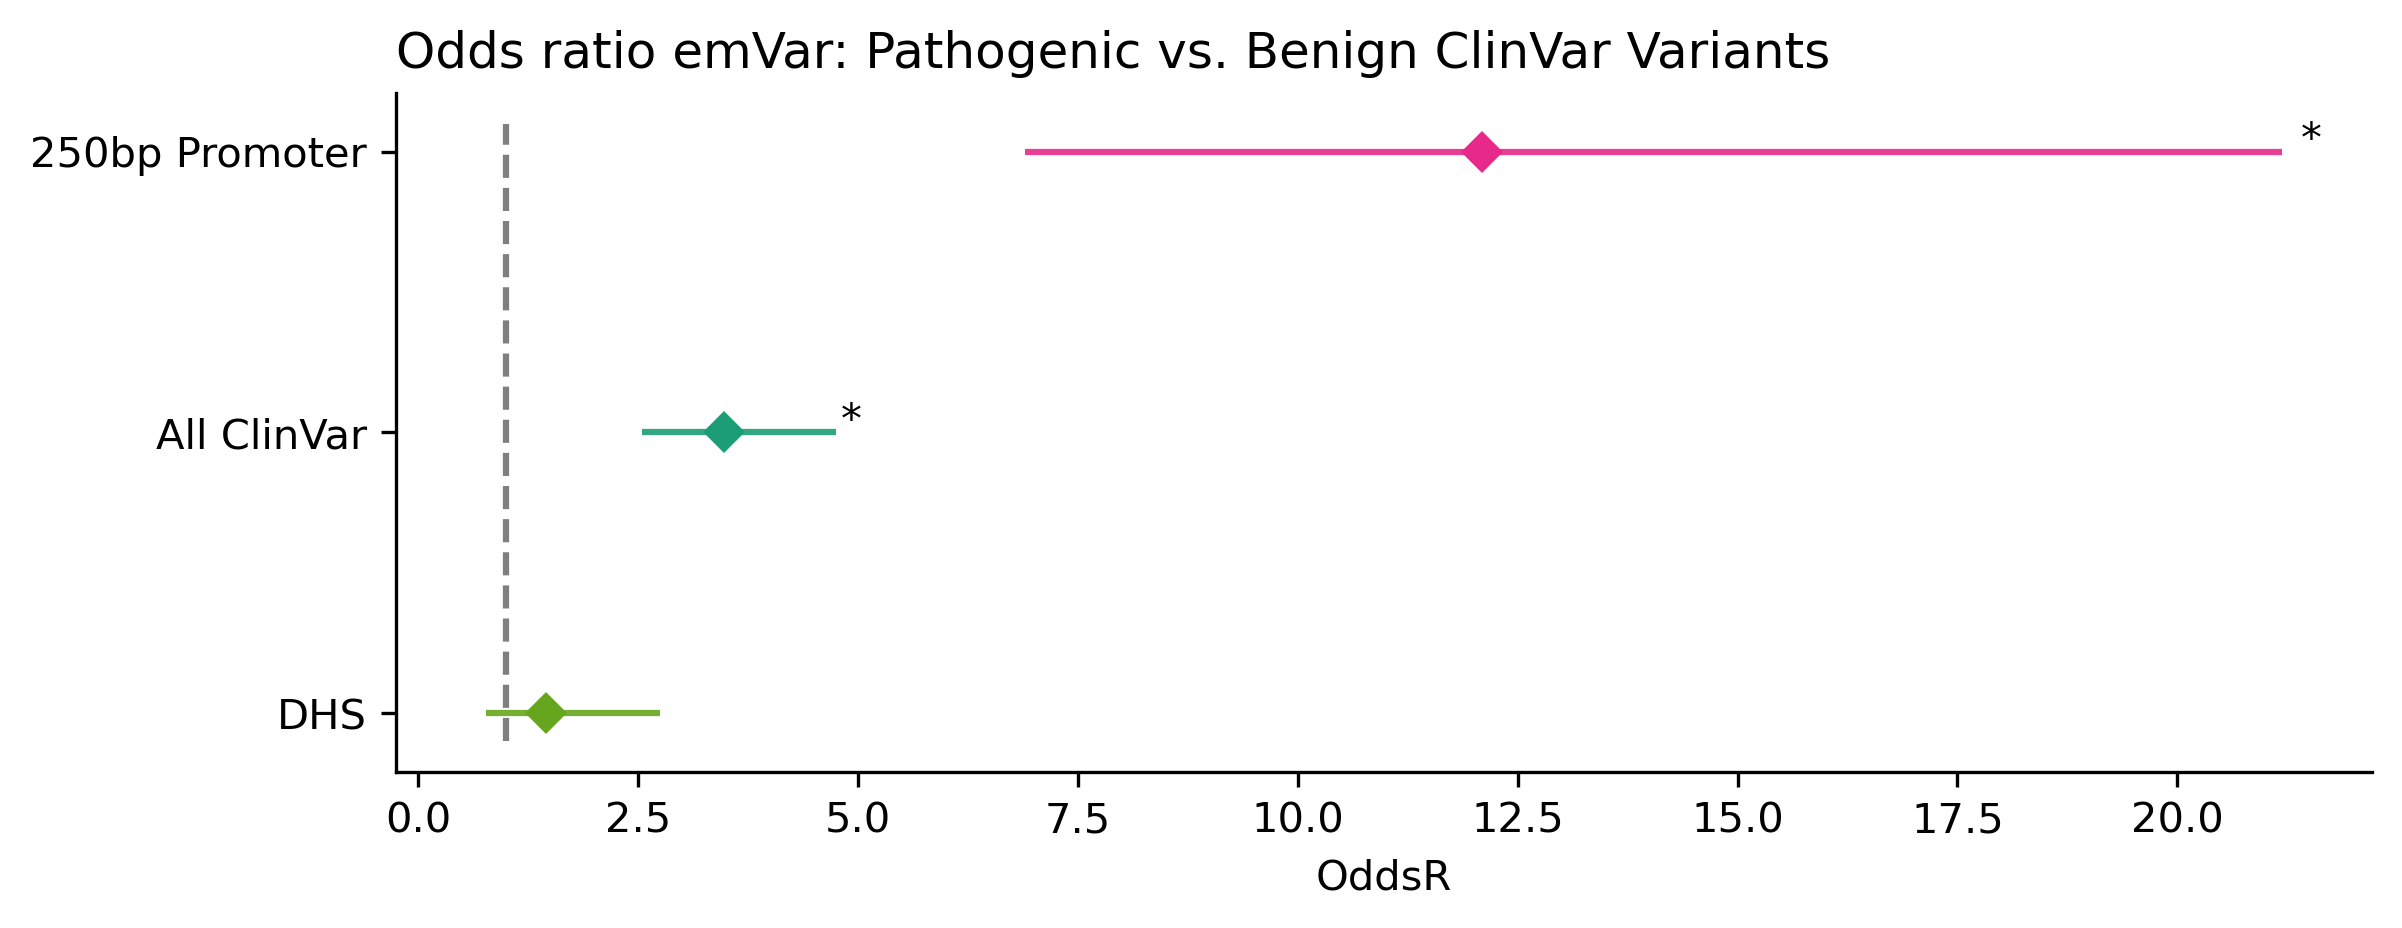

In [46]:
# plot oddsR of emVar in pathogenic vs benign variants by sequence feature #
mpl.figure(dpi=300, figsize=(8.5, 3))
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plots = sns.pointplot(
        data=cat_odds_or.sort_values(by='OddsR', ascending = False), x="OddsR", y="plot_labs",
        color="#1F271B", linestyle="none", marker="D", markersize=5, hue='plot_labs', palette=feature_palette
)
mpl.ylabel('')
for lower, upper, lab, pval in zip(cat_odds_or['lowerCI'],
                                   cat_odds_or['upperCI'],
                                   cat_odds_or['plot_labs'],
                                   cat_odds_or['p_val']):
    mpl.hlines(xmin=lower, xmax=upper, y=lab, color=feature_palette.get(lab), alpha=.9)
    if pval < .05:
        mpl.annotate('*', xy=(1.01 * upper, lab))
    else:
        continue
ymin, ymax = plots.get_ylim()
mpl.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
mpl.title('Odds ratio emVar: Pathogenic vs. Benign ClinVar Variants', loc='left')
sns.despine()
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/pathogenic_vs_benign_emvar_enrichments_nocCRE.pdf')

In [47]:
### Filter for Pathogenic and Benign Variants ###
# filter for only pathogenic, likely pathogenic, benign and likely benign variants for doing PRC
path_filter_preds = exon_filtered_preds[exon_filtered_preds['clinsig'].isin(['Pathogenic',
                                                                             'Likely_pathogenic',
                                                                             'Benign',
                                                                             'Likely_benign'])]
# add binary for pathogenicity
path_filter_preds['pathogenic'] = [1 if i in (['Pathogenic',
                                               'Likely_pathogenic']) else 0 for i in path_filter_preds['clinsig']]

/var/folders/58/97_f_jfx1yg65t5hxh4pl0pwn14x9s/T/ipykernel_71638/453926709.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  path_filter_preds['pathogenic'] = [1 if i in (['Pathogenic',


          feature  precision    recall
0  250bp Promoter   0.883333  0.092496
0             DHS   0.505543  0.397906
0             CRE   0.534314  0.380454


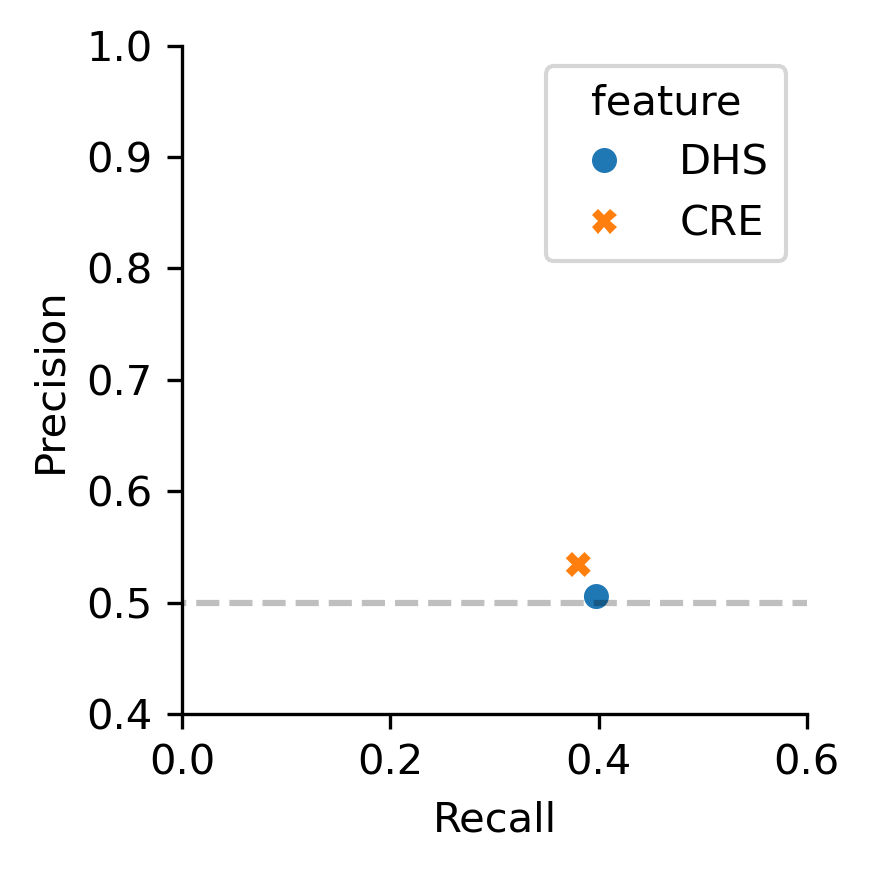

In [49]:
### Calculate Precision/Recall for Empirical Measures ###
# Get Precision/Recall for empirical features   
raw_prc_df, prc_results = empirical_precision_recall_cCREs(path_filter_preds)
# drop promoter from empirical precision recall
prc_results_no_pro = prc_results[prc_results['feature'] != '250bp Promoter']
### Plot Empirical Precision Recall ###
mpl.figure(dpi=300,
          figsize=(3,3))
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
sns.scatterplot(data=prc_results_no_pro,
                x='recall',
                y='precision',
                style='feature',
                hue='feature',
               linewidth=0)
mpl.xlim(0, .6)
mpl.ylim(.4, 1)
mpl.xlabel('Recall')
mpl.ylabel('Precision')
mpl.hlines(.5, 
           xmin=-.05, 
           xmax=1, 
           linestyles='dashed',
           color='k',
           alpha=.25)
#mpl.legend(bbox_to_anchor=(1.04, .5), loc="center left")
#mpl.title('Precision Recall of ClinVar Pathogenic Variants in Regulatory Elements', loc='left')
sns.despine()
mpl.tight_layout()
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/clinvar.empirical.precision.recall.pro.ccre.dhs.small.pdf')

In [50]:
# generate precision recall curves for mpac and sei predictions #
# open SEI predictions
sei_preds = pd.read_csv('/Users/buttsj/JAX Dropbox/John Butts/Variant_Effects/Kipoi_Comparisons/clinvar/all_clinvar_ncv_sei_dnase_preds_all_mal_cell_types.tsv',
                        sep = '\t')
# rename name column to id
sei_preds = sei_preds.rename(columns={'name' : 'id'})
# get hepg2 and k562 columns for calculating precision recall
sei_pred_cols = [i for i in sei_preds.keys() if 'K562' in i and 'ENCODE' in i or 'HepG2' in i and 'ENCODE' in i or 'SK-N-SH' in i and 'ENCODE' in i]
# get max prediction for each variant
maxCol = lambda x: max(x.min(), x.max(), key=abs)
sei_preds['sei_max_pred'] = sei_preds.filter(sei_pred_cols).apply(maxCol,
                                                              axis=1)
# merge predictions
mpac_sei_preds = exon_filtered_preds.merge(sei_preds, on='id')

In [51]:
# define a function for refactoring skews based on activity filter
def skew_refactor(df,
                  pred_type):
    # k562
    # get max activity
    df['k562_max_act'] = [abs(max([ref,alt], key=abs)) for ref, alt in zip(df[f'k562_ref_pred{pred_type}'],
                                                                           df[f'k562_alt_pred{pred_type}'])]
    # set skews of inactive variants to 0
    df['k562_refactor_skew'] = [abs(skew) if act > 1 else 0 for act, skew in zip(df['k562_max_act'],
                                                                                 df[f'k562_skew_pred{pred_type}'])]
    # hepg2
    # get max activity
    df['hepg2_max_act'] = [abs(max([ref,alt], key=abs)) for ref,alt in zip(df[f'hepg2_ref_pred{pred_type}'],
                                                                           df[f'hepg2_alt_pred{pred_type}'])]
    # set skews of inactive variants to 0
    df['hepg2_refactor_skew'] = [abs(skew) if act > 1 else 0 for act, skew in zip(df['hepg2_max_act'],
                                                                                  df[f'hepg2_skew_pred{pred_type}'])]
    # sknsh
    df['sknsh_max_act'] = [abs(max([ref,alt], key=abs)) for ref, alt in zip(df[f'sknsh_ref_pred{pred_type}'],
                                                                            df[f'sknsh_alt_pred{pred_type}'])]
    # set skews of inactivate variants to 0
    df['sknsh_refactor_skew'] = [abs(skew) if act > 1 else 0 for act, skew in zip(df['sknsh_max_act'],
                                                                                 df[f'sknsh_skew_pred{pred_type}'])]
    # take max skew
    df['abs_max'] = [max([k,h,s], key=abs) for k,h,s in zip(df['k562_refactor_skew'],
                                                           df['hepg2_refactor_skew'],
                                                           df['sknsh_refactor_skew'])]
    return df

In [52]:
# define function for calculating precision recall at each quantile
def precision_recall_clinvar (all_preds,
                            sei_col,
                            n_tests):
    # filter all clinvar for only pathogenic and benign variants for calculating quantiles
    path_benign = all_preds[all_preds['clinsig'].isin(['Pathogenic',
                                                       'Likely_pathogenic',
                                                       'Benign',
                                                       'Likely_benign'])]
    # make a dictionary for storing sklearn prc measures and metrics
    sei_sklearn_dict = {}
    mpac_no_act_sklearn_dict = {}
    sei_cre_dict = {}
    mpac_cre_dict = {}
    # iterate through columns and annotate hits/misses by quantile
    for test in tqdm(range(n_tests)):
        # split df into pathogenic and benign variants and make matched sample
        # pathogenic
        path_df = all_preds[all_preds['clinsig'].isin(['Pathogenic',
                                                       'Likely_pathogenic'])]
        # add binarized true col
        path_df['emp_true'] = [1 for i in range(len(path_df))]
        # benign
        benign_df = all_preds[all_preds['clinsig'].isin(['Benign',
                                                         'Likely_benign'])].sample(len(path_df))
        # add binarized true col
        benign_df['emp_true'] = [0 for i in range(len(benign_df))]
        # combine into single df
        df2prc = pd.concat([path_df,
                            benign_df])
        ### sei sklearn ### 
        # subset preds for sei cols only
        sei2prc = df2prc.filter(['id',
                                'emp_true',
                                'DHS'] + [sei_col])
        ### take absolute value of max call by sei for calculating sklearn precision recall curve/auc ###
        sei2prc['abs_max'] = [abs(i) for i in sei2prc[sei_col]]
        # calculate precision recall by sklearn metrics
        sei_pre, sei_rec, sei_thresholds = precision_recall_curve(sei2prc['emp_true'],
                                                                  sei2prc['abs_max'])
        sei_auc = metrics.auc(sei_rec,
                              sei_pre)
        # sei_test_N : tuple(precision, recall, thresholds, auc, df)
        sei_sklearn_dict.update({f'sei_test_{test}' : (sei_pre,
                                                             sei_rec,
                                                             sei_thresholds,
                                                             sei_auc,
                                                             sei2prc)})
        ### mpacsklearn ###
        # calculate precision and recall for MPAC
        mpac2prc = df2prc.filter(['id',
                                      'emp_true',
                                      'k562_ref_pred',
                                      'k562_alt_pred',
                                      'hepg2_ref_pred',
                                      'hepg2_alt_pred',
                                      'sknsh_ref_pred',
                                      'sknsh_alt_pred',
                                      'k562_skew_pred',
                                      'hepg2_skew_pred',
                                      'sknsh_skew_pred',
                                      'DHS'])
        # make a copy of mpac2prc for no activity filter calls
        mpac4prc = mpac2prc.copy()
        # use sklearn to calculate auc for no activity considered malinois preds
        mpac4prc['abs_max'] = [abs(max([i,
                                        j,
                                        k], key=abs)) for i,j,k in zip(mpac4prc['k562_skew_pred'],
                                                                       mpac4prc['hepg2_skew_pred'],
                                                                       mpac4prc['sknsh_skew_pred'])]
        mpac_pre, mpac_rec, mpac_thresh = precision_recall_curve(mpac4prc['emp_true'],
                                                                 mpac4prc['abs_max'])
        mpac_no_act_auc = metrics.auc(mpac_rec,
                                     mpac_pre)
        # malinois_test_N : tuple(precsion, recall, thresholds, auc, df)
        mpac_no_act_sklearn_dict.update({f'MPAC_Test_{test}' : (mpac_pre,
                                                                mpac_rec,
                                                                mpac_thresh,
                                                                mpac_no_act_auc,
                                                                mpac4prc)})
        ### SEI + CRE ###
        # refactor skews - set to 0 if variant not in CRE #
        sei2prc['cre_refactor'] = [abs(skew) if dhs == 1 else 0 for dhs, skew in zip(sei2prc['DHS'],
                                                                                     sei2prc['abs_max'])]
        sei_cre_pre, sei_cre_rec, sei_cre_thresh = precision_recall_curve(sei2prc['emp_true'],
                                                                          sei2prc['cre_refactor'])
        sei_cre_pre = sei_cre_pre[1:]
        sei_cre_rec = sei_cre_rec[1:]
        sei_cre_auc= metrics.auc(sei_cre_rec,
                                 sei_cre_pre)
        sei_cre_dict.update({f'sei_CRE_test_{test}' : (sei_cre_pre,
                                                      sei_cre_rec,
                                                      sei_cre_thresh,
                                                      sei_cre_auc,
                                                      sei2prc)})
        ### MPAC + CRE ###
        # refactor skews - set to 0 if variant not in CRE #
        mpac4prc['cre_refactor'] = [abs(skew) if dhs == 1 else 0 for dhs, skew in zip(mpac4prc['DHS'],
                                                                                      mpac4prc['abs_max'])]
        mpac_cre_pre, mpac_cre_rec, mpac_cre_thresh = precision_recall_curve(mpac4prc['emp_true'],
                                                                             mpac4prc['cre_refactor'])
        mpac_cre_pre = mpac_cre_pre[1:]
        mpac_cre_rec = mpac_cre_rec[1:]
        mpac_cre_auc= metrics.auc(mpac_cre_rec,
                                  mpac_cre_pre)
        mpac_cre_dict.update({f'MPAC_CRE_test_{test}' : (mpac_cre_pre,
                                                         mpac_cre_rec,
                                                         mpac_cre_thresh,
                                                         mpac_cre_auc,
                                                         mpac4prc)})
    print(len(path_df))
    print(len(path_benign[path_benign['clinsig'].isin(['Benign', 'Likely_benign'])]))
            
    return sei_sklearn_dict, mpac_no_act_sklearn_dict;

In [53]:
# calculate PRCs for SEI and MPAC
# With Activity Filter #
### All ClinVar ###
all_sei_sklearn, mpac_sklearn = precision_recall_clinvar(mpac_sei_preds,
                                                        'sei_max_pred',
                                                        100)

  0%|                                                                                                                                                          | 0/100 [00:00<?, ?it/s]/var/folders/58/97_f_jfx1yg65t5hxh4pl0pwn14x9s/T/ipykernel_71638/3600354992.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  path_df['emp_true'] = [1 for i in range(len(path_df))]
/var/folders/58/97_f_jfx1yg65t5hxh4pl0pwn14x9s/T/ipykernel_71638/3600354992.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  path_df['emp_tru

573
162232


In [54]:
### DHS ###
# With Activity Filter #
dhs_sei_sklearn, mpac_dhs_sklearn = precision_recall_clinvar(mpac_sei_preds[mpac_sei_preds['DHS'] == 1],
                                                            'sei_max_pred',
                                                            100)

  0%|                                                                                                                                                          | 0/100 [00:00<?, ?it/s]/var/folders/58/97_f_jfx1yg65t5hxh4pl0pwn14x9s/T/ipykernel_71638/3600354992.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  path_df['emp_true'] = [1 for i in range(len(path_df))]
/var/folders/58/97_f_jfx1yg65t5hxh4pl0pwn14x9s/T/ipykernel_71638/3600354992.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  path_df['emp_tru

228
56987


In [55]:
### 250bp Promoter ###
# with activity filter #
pro_sei_sklearn, mpac_pro_sklearn = precision_recall_clinvar(mpac_sei_preds[mpac_sei_preds['250bp_promoter'] == 1],
                                                           'sei_max_pred',
                                                           100)

  0%|                                                                                                                                                          | 0/100 [00:00<?, ?it/s]/var/folders/58/97_f_jfx1yg65t5hxh4pl0pwn14x9s/T/ipykernel_71638/3600354992.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  path_df['emp_true'] = [1 for i in range(len(path_df))]
/var/folders/58/97_f_jfx1yg65t5hxh4pl0pwn14x9s/T/ipykernel_71638/3600354992.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  path_df['emp_tru

53
2472


In [56]:
# make a dictionary for model coloring
model_palette = {#'Malinois' : '#43AA8B',
                 'MPAC' : '#9ecae1',
                 'Sei DHS' : "#1f77b4",
                 'MPAC Max' : "#2ca02c",
                 'MPAC Avg Activity > 1' : "#ff7f0e",
                 'MPAC Center Activity > 1' : "#1f77b4",
                 'MPAC Max Activity > 1' : "#2ca02c",
                 'Sei' : '#fd8d3c'}#,
                 #'phyloP' : '#F9C74F',
                 #'deepSEA' : '#90BE6D',
                 #'jarvis' : '#F94144',
                 #'CADD - Norm' : 'k'}
# make a dict for linestyle
line_palette = {#'Malinois' : '#43AA8B',
                 'MPAC' : "solid",
                 'MPAC Center' : "solid",
                 'MPAC Max' : "solid",
                 'MPAC Avg Activity > 1' : "dashed",
                 'MPAC Center Activity > 1' : "dashed",
                 'MPAC Max Activity > 1' : "dashed",
                 'Sei' : 'solid'}
bar_palette = {#'Malinois' : '#43AA8B',
                 'MPAC' : '#9ecae1',
                 'MPAC Center' : "#1f77b4",
                 'MPAC Max' : "#2ca02c",
                 'MPAC Avg Activity > 1' : "#ffd9b7",
                 'MPAC Center Activity > 1' : "#b2d8f2",
                 'MPAC Max Activity > 1' : "#b7ebb7",
                 'Sei' : '#fd8d3c'}

In [57]:
# define function to concatenate sklearn prc outputs into DF and return plot 
def sklearn_summary_sei_mpac (list_of_dicts,
                    dict_labels,
                    clinvar_feature,
                    path2plot_out,
                    path2summary_out):
    dfs2concat = []
    auc2concat = []
    # iterate through list of dicts and concatenate
    for prc_dict, model in zip(list_of_dicts,
                               dict_labels):
        # concatenate precision/recall data
        df2concat = pd.concat([pd.DataFrame({'Precision' : i[0],
                                             'Recall' : i[1]}) for i in prc_dict.values()])
        # add model label to dictionary for coloring
        df2concat['Model'] = [model for i in range(len(df2concat))]
        # append to list
        dfs2concat.append(df2concat)
        # get average auc
        auc2concat.append(pd.DataFrame({'Model' : [model],
                                        'Mean_AUC' : [np.mean([i[-2] for i in prc_dict.values()])],
                                        'Feature' : [clinvar_feature]}))
    auc_df = pd.concat(auc2concat)
    # save to disk
    #auc_df.to_csv(path2summary_out,
    #              sep = '\t',
    #              index = False)
    # concatenate data
    all_data = pd.concat(dfs2concat)
    # plot concatenated data
    mpl.figure(dpi=300)
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42
    # plot no activity filter
    sns.lineplot(data=all_data[all_data['Model'].isin(['MPAC', 'Sei'])],
                     x='Recall',
                     y='Precision',
                     hue='Model',
                     rasterized=True,
                     linestyle='solid',#,
                     palette=model_palette)
                 #errorbar=None)
    mpl.title(clinvar_feature, loc='left')
    mpl.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyles='dashed')
    mpl.ylim(.45, 1.05)
    mpl.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    sns.despine()
    #mpl.savefig(path2plot_out)

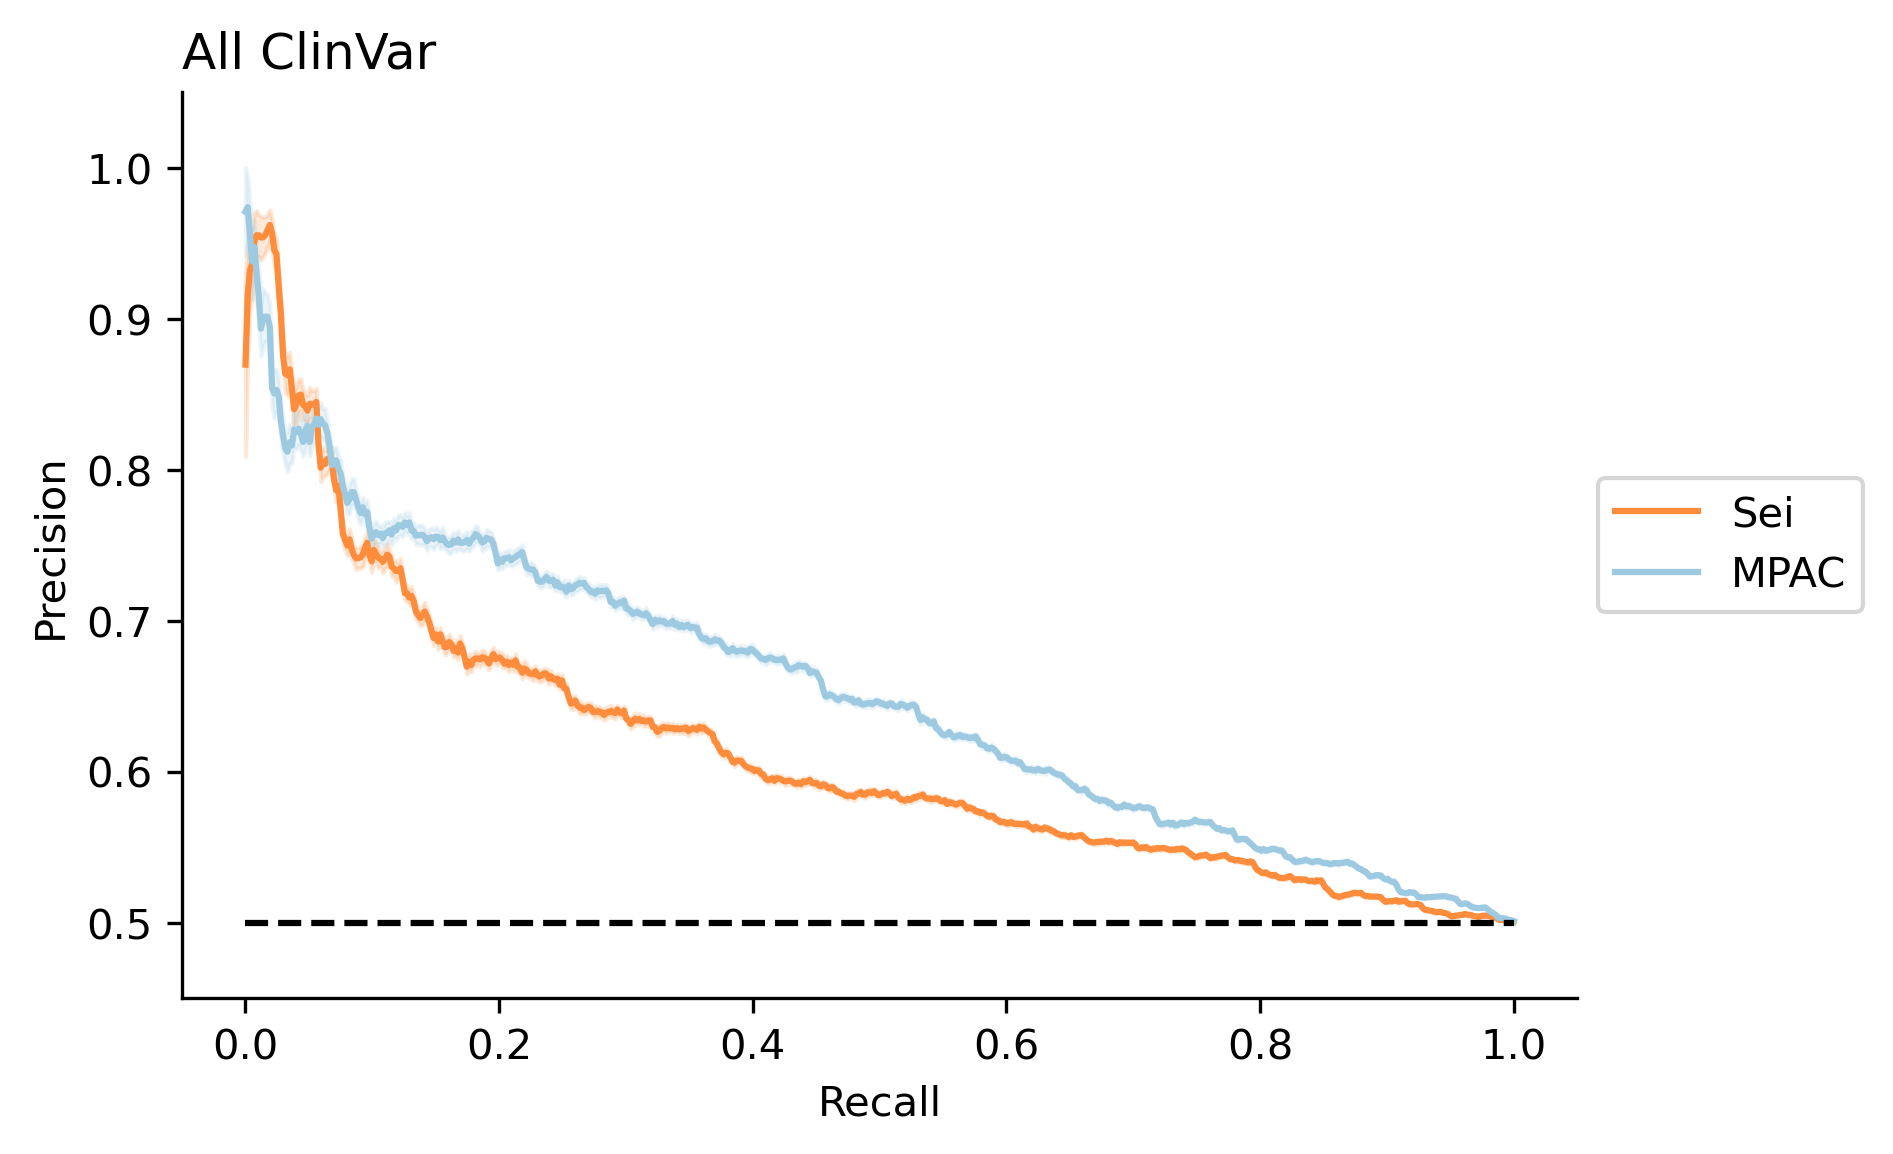

In [58]:
# All ClinVar
sklearn_summary_sei_mpac([all_sei_sklearn, mpac_sklearn],
                ['Sei',
                'MPAC'],
                'All ClinVar',
                '',
                '')

In [59]:
# define function to pull precision at specified skew thresholds
def get_precision_from_thresh(sklearn_dict,
                             list_of_skews,
                             pred_type,
                             shape):
    # make dictionaries for storing mean precision/recall for each skew threshold - value is a tuple with:
    #                                                          mean precision [0], pre_lowerCI [1], pre_upperCI [2], mean recall [3],  and pred type [-1]
    dict2return = {}
    # iterate through each skew threshold
    for skew in list_of_skews:
        precision2mean = []
        recall2mean = []
        # define range for filtering precision
        upperThresh = 1.025 * skew
        lowerThresh = .975 * skew
        # get all dict values
        all_tests = list(sklearn_dict.keys())
        # iterate through tests
        for test in all_tests:
            # get thresholds
            all_thresholds = sklearn_dict.get(test)[2]
            # get precisions
            all_precision = sklearn_dict.get(test)[0]
            # get all recall
            total_recall = sklearn_dict.get(test)[1]
            # get indices of skew thresholds in within 2.5% of the current skew threshold
            min_thresh = min([i for i,j in enumerate(all_thresholds > (skew * .95)) if j == True])
            max_thresh = max([i for i,j in enumerate(all_thresholds < (skew * 1.5)) if j == True])
            # subset all precision for those in skew range
            skew_precision = all_precision[ min_thresh : max_thresh ]
            # subset (total) recall for those in skew range
            skew_recall = total_recall[ min_thresh : max_thresh ]
            # append all skew precisions to precision to mean to get mean precision
            [precision2mean.append(i) for i in skew_precision]
            # append all skew recalls to recall to mean to get mean recall
            [recall2mean.append(i) for i in skew_recall]
        # calculate confidence intervals for precision
        pre_lower, pre_upper = stats.t.interval(0.95, len(precision2mean)-1, loc=np.mean(precision2mean), scale=stats.sem(precision2mean))
        # update dict
        dict2return.update({skew : (np.mean(precision2mean),
                                    pre_lower,
                                    pre_upper,
                                    np.mean(recall2mean),
                                    pred_type,
                                    shape)})
    # create a sorted list for calling dict values
    sorted_skews = sorted(list(dict2return.keys()))
    # build a DF to plot
    df2return = pd.DataFrame({'Skew Threshold' : sorted_skews,
                              'Mean Precision' : [dict2return.get(i)[0] for i in sorted_skews],
                              'Precision lower95' : [dict2return.get(i)[1] for i in sorted_skews],
                              'Precision upper95' : [dict2return.get(i)[2] for i in sorted_skews],
                              'Mean Recall' : [dict2return.get(i)[3] for i in sorted_skews],
                              'Prediction' : [dict2return.get(i)[-2] for i in sorted_skews],
                              'Shape' : [dict2return.get(i)[-1] for i in sorted_skews]})
    return df2return

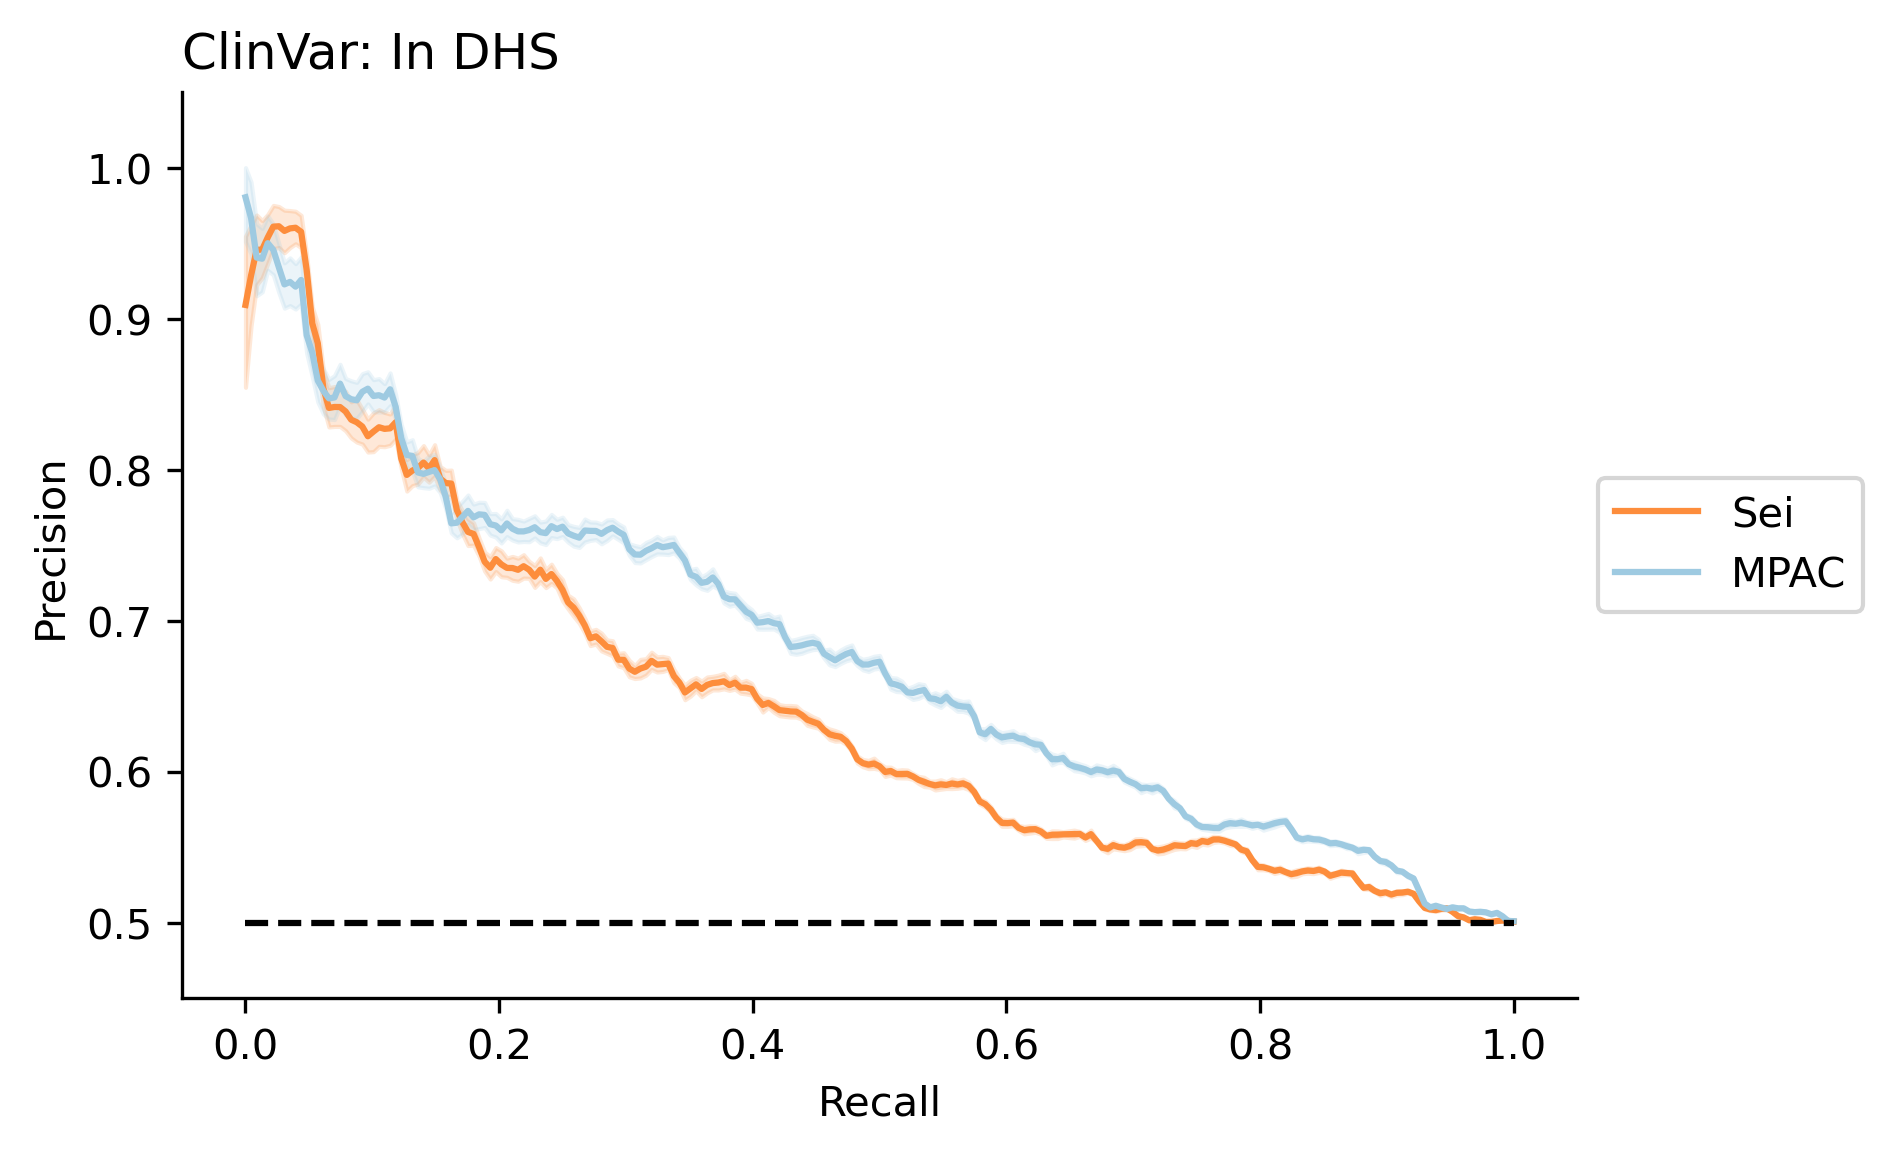

In [60]:
# ClinVar: DHS
sklearn_summary_sei_mpac([dhs_sei_sklearn,
                 mpac_dhs_sklearn],
                ['Sei',
                'MPAC'],
                'ClinVar: In DHS',
                '/Users/buttsj/Dropbox (JAX)/Variant_Effects/Kipoi_Comparisons/clinvar/prc_plots/All_ClinVar_PRC_v3.pdf',
                '/Users/buttsj/Dropbox (JAX)/Variant_Effects/Kipoi_Comparisons/clinvar/prc_plots/All_ClinVar_Mean_AUC_v3.txt')

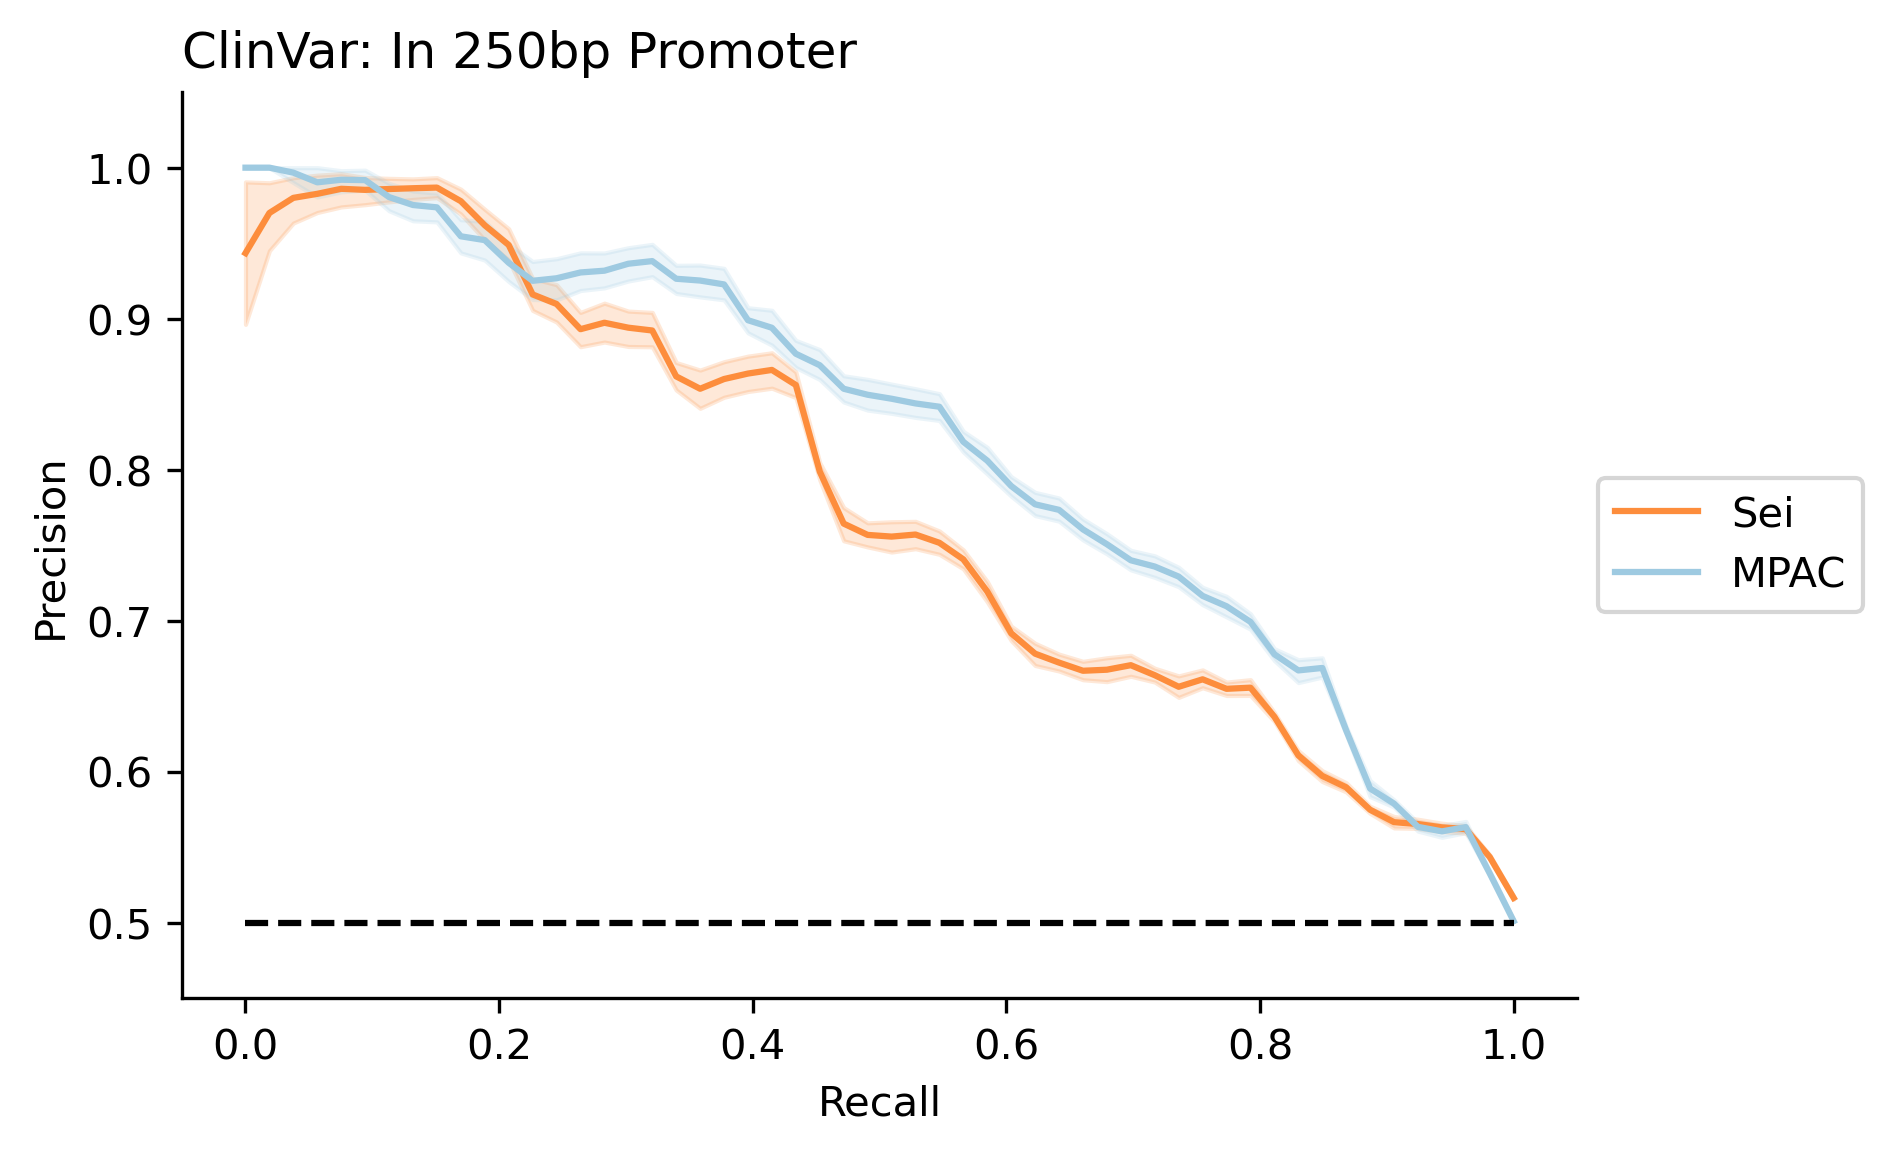

In [61]:
# ClinVar:250bp Promoter
sklearn_summary_sei_mpac([pro_sei_sklearn, 
                 mpac_pro_sklearn],
                ['Sei',
                'MPAC'],
                'ClinVar: In 250bp Promoter',
                '/Users/buttsj/Dropbox (JAX)/Variant_Effects/Kipoi_Comparisons/clinvar/prc_plots/All_ClinVar_PRC_v3.pdf',
                '/Users/buttsj/Dropbox (JAX)/Variant_Effects/Kipoi_Comparisons/clinvar/prc_plots/All_ClinVar_Mean_AUC_v3.txt')

In [62]:
# define function to concatenate sklearn prc outputs into DF and return plot 
def sklearn_4_grid (list_of_dicts,
                    dict_labels,
                    clinvar_feature,
                    path2summary_out):
    dfs2concat = []
    auc2concat = []
    # iterate through list of dicts and concatenate
    for prc_dict, model in zip(list_of_dicts,
                               dict_labels):
        # concatenate precision/recall data
        df2concat = pd.concat([pd.DataFrame({'Precision' : i[0],
                                             'Recall' : i[1]}) for i in prc_dict.values()])
        # add model label to dictionary for coloring
        df2concat['Model'] = [model for i in range(len(df2concat))]
        # append to list
        dfs2concat.append(df2concat)
        # get 95% CIs
        lowerCI, upperCI = stats.t.interval(0.95, len([i[-2] for i in prc_dict.values()])-1, 
                                          loc=np.mean([i[-2] for i in prc_dict.values()]), 
                                          scale=stats.sem([i[-2] for i in prc_dict.values()]))
        # get average auc
        auc2concat.append(pd.DataFrame({'Model' : [model],
                                        'Mean_AUC' : [np.mean([i[-2] for i in prc_dict.values()])],
                                        'lower_CI' : [lowerCI],
                                        'upper_CI' : [upperCI],
                                        'Feature' : [clinvar_feature]}))
    auc_df = pd.concat(auc2concat)
    # save to disk
    auc_df.to_csv(path2summary_out,
                  sep = '\t',
                  index = False)
    df2return = pd.concat(dfs2concat)
    return df2return

In [63]:
# concatenate DFs for plotting PRCs as 2x2 grid for final figure #
# All ClinVar
all_4_grid = sklearn_4_grid([all_sei_sklearn,
                             mpac_sklearn],
                            ['Sei',
                             'MPAC'],
                             'All ClinVar',
                             '/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/All_ClinVar_Mean_AUC.v4.txt')
# DHS
dhs_4_grid = sklearn_4_grid([dhs_sei_sklearn,
                            mpac_dhs_sklearn],
                            ['Sei',
                             'MPAC'],
                            'ClinVar: In DHS',
                            '/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/DHS_ClinVar_Mean_AUC.v4.txt')
# 250bp Promoter
twoFifty_4_grid = sklearn_4_grid([pro_sei_sklearn,
                                  mpac_pro_sklearn],
                                 ['Sei',
                                 'MPAC'],
                                'ClinVar: In 250bp Promoter',
                                '/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/250bp_Promoter_ClinVar_Mean_AUC.v4.txt')

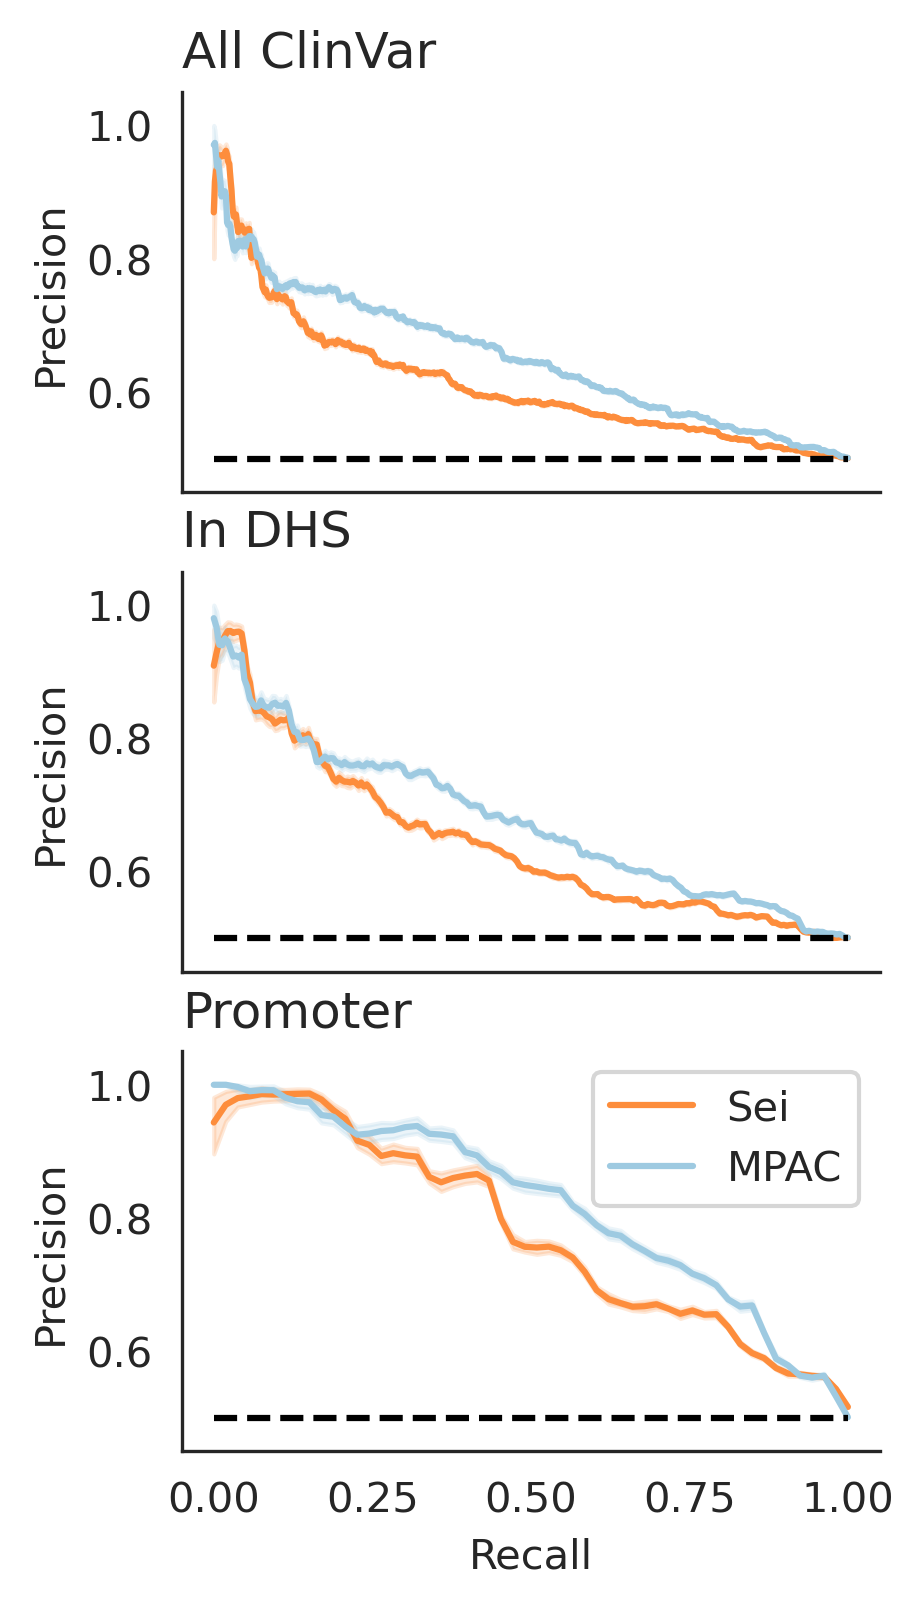

In [64]:
# plot in square grid
f = mpl.figure(figsize=(3, 6), dpi=300)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(3,1)
# Plot All ClinVar
with sns.axes_style("white"):
    ax_01 = f.add_subplot(gs[0,0])
    sns.lineplot(data=all_4_grid,
                 x='Recall',
                 y='Precision',
                 hue='Model',
                 palette=model_palette,
                 rasterized=True,
                 legend=False)
    mpl.title('All ClinVar', loc='left')
    mpl.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyles='dashed')
    mpl.ylim(.45, 1.05)
    mpl.xlabel('')
    mpl.xticks([])
# Plot in DHS
with sns.axes_style("white"):
    ax_02 = f.add_subplot(gs[1,0])
    sns.lineplot(data=dhs_4_grid,
                 x='Recall',
                 y='Precision',
                 hue='Model',
                 palette=model_palette,
                 rasterized=True,
                 legend=False)
    mpl.title('In DHS', loc='left')
    mpl.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyles='dashed')
    mpl.ylim(.45, 1.05)
    mpl.xlabel('')
    mpl.xticks([])
# Plot in 250bp Promoter
with sns.axes_style("white"):
    ax_04 = f.add_subplot(gs[2,0])
    sns.lineplot(data=twoFifty_4_grid,
                 x='Recall',
                 y='Precision',
                 hue='Model',
                 palette=model_palette,
                 rasterized=True,
                 legend=True)
    mpl.title('Promoter', loc='left')
    mpl.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyles='dashed')
    mpl.legend(loc='upper right')
    mpl.ylim(.45, 1.05)
sns.despine()
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/row_prc_sei_mpac_no_cre.pdf')

In [65]:
# define a function for calculating mean precision at empirical recall #
def get_mpac_pre_at_recall (empirical_recall,
                            pre_rec_dict):
    # make list of precisions
    pre_list = [list(pre_rec_dict.get(i)[0]) for i in pre_rec_dict.keys()]
    # make list of recalls
    rec_list = [list(pre_rec_dict.get(i)[1]) for i in pre_rec_dict.keys()]
    # iterate through list of of recalls and get indices of recalls in the emprical range
    emp_upper = empirical_recall * 1.01
    emp_lower = empirical_recall * .99
    # get indices
    precisions = []
    for recall_list, precision_list in zip(rec_list, pre_list):
        # update indices list with the recalls in the range of these values
        indices = [i for i,j in enumerate(recall_list) if j > emp_lower and j < emp_upper]
        # append mean precision at those recalls to list
        precisions.append(np.mean(precision_list[min(indices):max(indices)+1]))
    mean_precision = np.mean(precisions)
    print(f'The mean MPAC precision at the empirical recall: {empirical_recall} is {mean_precision}')
    return mean_precision

  Model  Mean_AUC  lower_CI  upper_CI                     Feature
0   Sei  0.612790  0.610682  0.614897                 All ClinVar
1  MPAC  0.651241  0.648810  0.653672                 All ClinVar
0   Sei  0.779944  0.774003  0.785884  ClinVar: In 250bp Promoter
1  MPAC  0.822382  0.816346  0.828418  ClinVar: In 250bp Promoter
0   Sei  0.643380  0.639985  0.646774             ClinVar: In DHS
1  MPAC  0.677137  0.673274  0.680999             ClinVar: In DHS


Text(0.0, 1.0, 'Mean AUC of ClinVar Pathogenic Variants')

<Figure size 1200x1800 with 0 Axes>

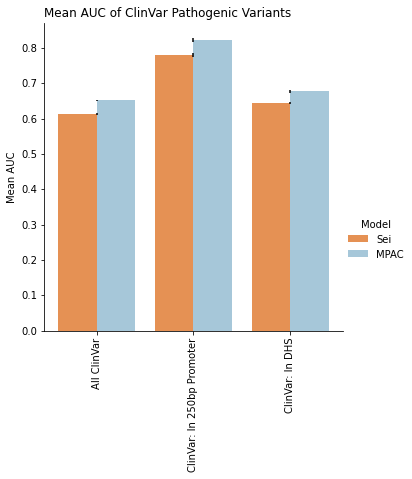

In [66]:
# plot mean AUC as a bar plot for summarizing figures
mean_auc2plot = pd.concat([pd.read_csv(i,
                                       sep = '\t') for i in ['/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/All_ClinVar_Mean_AUC.v4.txt',
                                                            '/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/DHS_ClinVar_Mean_AUC.v4.txt',
                                                            '/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/250bp_Promoter_ClinVar_Mean_AUC.v4.txt']]).sort_values(by=['Feature',
                                                                                                                                                                                                                 'Mean_AUC'])
print(mean_auc2plot)
# make a bar plot of above mean AUCs
mpl.figure(dpi=300, figsize=(4,6))
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
sns.catplot(data=mean_auc2plot,
            x='Feature',
            y='Mean_AUC',
            hue='Model',
            palette=bar_palette,
            kind='bar')
for lower, upper, lab in zip(mean_auc2plot['lower_CI'],
                            mean_auc2plot['upper_CI'],
                            mean_auc2plot['Feature']):
    mpl.vlines(x=lab, ymin=lower, ymax=upper, color='k')
mpl.xticks(rotation=90)
mpl.ylabel('Mean AUC')
mpl.xlabel('')
#mpl.ylim(.4, 1)
mpl.title('Mean AUC of ClinVar Pathogenic Variants', loc='left')
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_2/mean_AUC_bar_plot.pdf')

In [67]:
# define a function for calculating mean precision at empirical recall #
def get_mpac_pre_at_recall (empirical_recall,
                            pre_rec_dict):
    # make list of precisions
    pre_list = [list(pre_rec_dict.get(i)[0]) for i in pre_rec_dict.keys()]
    # make list of recalls
    rec_list = [list(pre_rec_dict.get(i)[1]) for i in pre_rec_dict.keys()]
    # iterate through list of of recalls and get indices of recalls in the emprical range
    emp_upper = empirical_recall * 1.01
    emp_lower = empirical_recall * .99
    # get indices
    precisions = []
    for recall_list, precision_list in zip(rec_list, pre_list):
        # update indices list with the recalls in the range of these values
        indices = [i for i,j in enumerate(recall_list) if j > emp_lower and j < emp_upper]
        # append mean precision at those recalls to list
        precisions.append(np.mean(precision_list[min(indices):max(indices)+1]))
    mean_precision = np.mean(precisions)
    print(f'The mean MPAC precision at the empirical recall: {empirical_recall} is {mean_precision}')
    return mean_precision

In [68]:
# get MPAC precision at empirical threshold for DHS
get_mpac_pre_at_recall(prc_results_no_pro[prc_results_no_pro['feature'] == 'DHS']['recall'].tolist()[0],
                       mpac_sklearn)

The mean MPAC precision at the empirical recall: 0.39790575916230364 is 0.680447495239111


0.680447495239111

In [69]:
# get MPAC precision at empirical threshold for DHS
get_mpac_pre_at_recall(prc_results_no_pro[prc_results_no_pro['feature'] == 'DHS']['recall'].tolist()[0],
                       all_sei_sklearn)

The mean MPAC precision at the empirical recall: 0.39790575916230364 is 0.6026144866919045


0.6026144866919045